# Task 4: Predicting Insurance Claim Amounts

**Internship:** DevelopersHub Corporation — Data Science & Analytics  
**Name:** Muneeb Ur Rehman  
**Email:** mu181842@gmail.com  
**GitHub:** https://github.com/muneeb-914/insurance-charges-prediction

---

## Problem Statement
Insurance companies need to estimate how much a customer will cost them in medical claims. Accurate predictions allow better pricing of insurance plans and risk management.

In this task, we build a **Linear Regression model** to predict medical insurance charges based on personal attributes like age, BMI, smoking status, and region.

---

## Dataset Description
| Property | Value |
|----------|-------|
| Source | Kaggle — Medical Cost Personal Dataset |
| Rows | 1,338 |
| Columns | 7 |
| Target | charges (USD) |
| Missing Values | None |

**Key Features:**
- **age** — Age of the insured person
- **bmi** — Body Mass Index
- **smoker** — Whether the person smokes (yes/no)
- **sex** — Gender (male/female)
- **children** — Number of dependents
- **region** — Geographic region (northeast, northwest, southeast, southwest)

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('raw_data/insurance.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Data Types:\n', df.dtypes)
df.head()

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())
print("\nSmoker Distribution:")
print(df['smoker'].value_counts())
print("\nSex Distribution:")
print(df['sex'].value_counts())

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Smoker Distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Sex Distribution:
sex
male      676
female    662
Name: count, dtype: int64


## Step 1: Exploratory Data Analysis (EDA)
Visualizing charge distributions, smoking impact, BMI relationship, and age patterns to understand what drives high insurance costs.

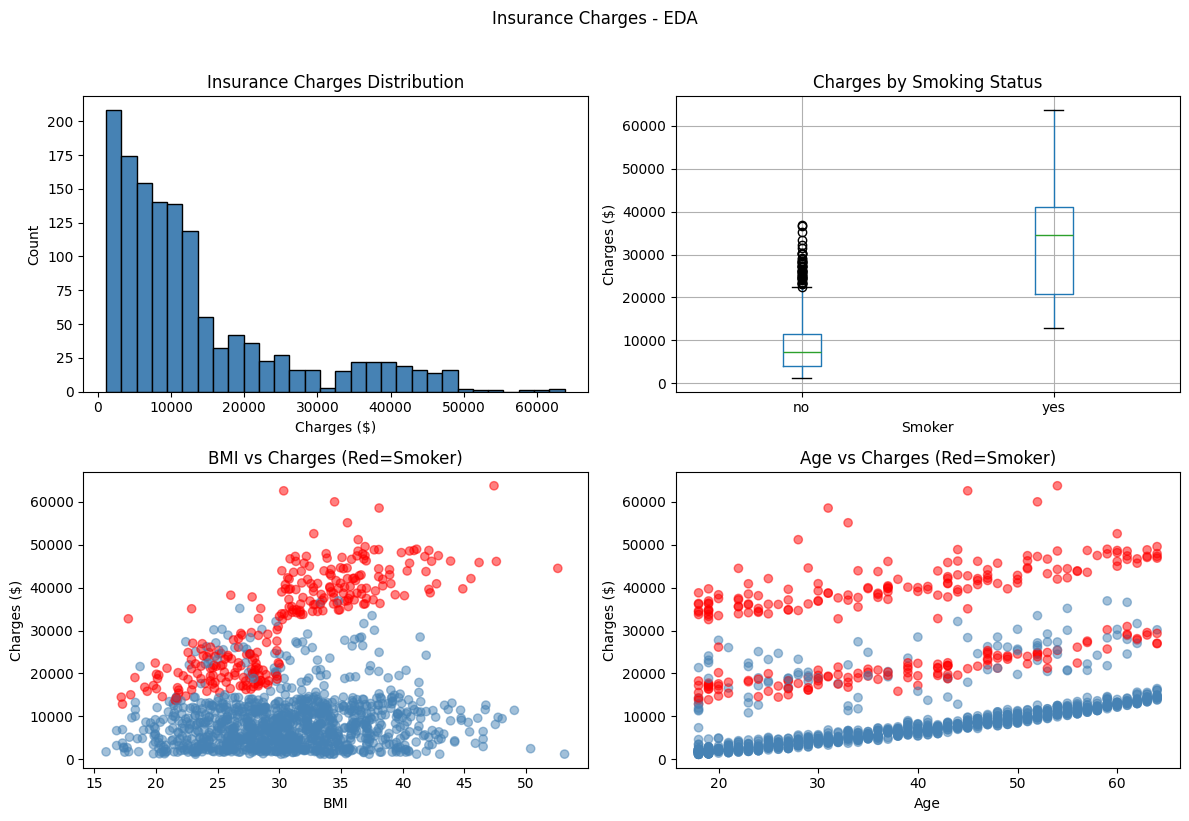

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Charges Distribution
axes[0,0].hist(df['charges'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Insurance Charges Distribution')
axes[0,0].set_xlabel('Charges ($)')
axes[0,0].set_ylabel('Count')

# Smoker vs Charges
df.boxplot(column='charges', by='smoker', ax=axes[0,1])
axes[0,1].set_title('Charges by Smoking Status')
axes[0,1].set_xlabel('Smoker')
axes[0,1].set_ylabel('Charges ($)')

# BMI vs Charges
axes[1,0].scatter(df['bmi'], df['charges'], 
                   c=df['smoker'].map({'yes':'red','no':'steelblue'}),
                   alpha=0.5)
axes[1,0].set_title('BMI vs Charges (Red=Smoker)')
axes[1,0].set_xlabel('BMI')
axes[1,0].set_ylabel('Charges ($)')

# Age vs Charges
axes[1,1].scatter(df['age'], df['charges'],
                   c=df['smoker'].map({'yes':'red','no':'steelblue'}),
                   alpha=0.5)
axes[1,1].set_title('Age vs Charges (Red=Smoker)')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Charges ($)')

plt.suptitle('Insurance Charges - EDA', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()

## Step 2: Feature Engineering & Model Training
Encoding categorical columns (sex, smoker, region) using Label Encoding and training a Linear Regression model to predict insurance charges.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# Features and target
X = df.drop(columns=['charges'])
y = df['charges']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Model trained!
Train: 1070 samples, Test: 268 samples


## Step 3: Model Evaluation
Measuring prediction accuracy using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error), and visualizing actual vs predicted charges.

MAE:  $4186.51
RMSE: $5799.59
R² Score: 0.7833


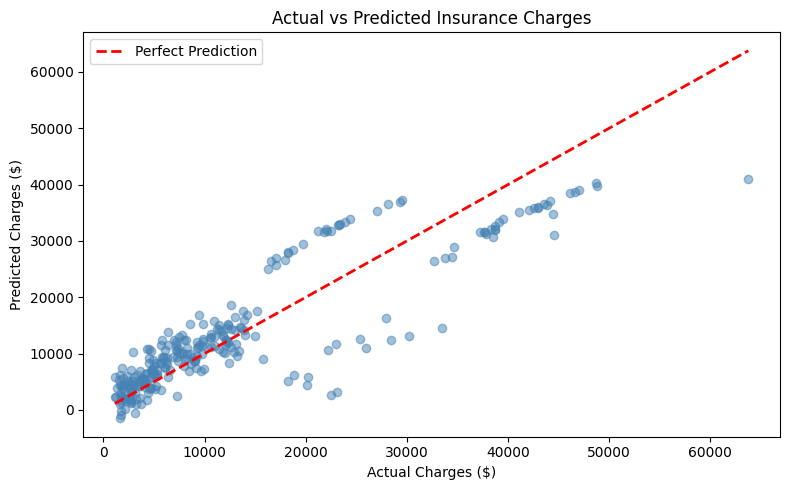

In [13]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

## Conclusion & Key Insights

### Model Performance:
- **R² Score: 0.7833** — model explains 78.33% of charge variation
- **MAE: $4,186** — on average predictions are $4,186 off
- **RMSE: $5,799** — larger errors exist for extreme cases (smokers with high BMI)

### Business Insights:
1. **Smokers pay 5x more** — median non-smoker charges ~$7,000 vs smokers ~$35,000
2. **BMI + Smoking = highest risk** — this combination pushes charges to $30,000-$60,000
3. **Age increases charges gradually** for non-smokers but smoking creates a completely separate cost tier
4. **Only 274 out of 1,338 (20%) are smokers** yet they dominate the high-cost claims
5. **Gender and region have minimal impact** on charges compared to smoking status

### Recommendation:
Insurance companies should heavily weight smoking status in their pricing models. A smoker with high BMI should be priced in a completely different tier. Non-smokers with normal BMI represent the lowest risk group.

### Technologies Used
- **Python** — Programming language
- **Pandas** — Data manipulation
- **Scikit-learn** — Linear Regression, LabelEncoder
- **Matplotlib & Seaborn** — Visualizations